<a href="https://colab.research.google.com/github/RvXp/Topicos-Especiais-em-IA-LLM/blob/main/visualizacao_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5: Embeddings com modelo *encoder-only* e visualização

Nesta prática você vai usar embeddings e verificar visualmente a intuição de que conceitos semânticos estão espacialmente próximos nos embeddings.

O roteiro é:

1. **Carregar um modelo *encoder-only* para embeddings**.
2. **Gerar embeddings por sentença** para uma coleção de documentos.
3. **Reduzir a dimensionalidade** e **plotar em 2D** para inspecionar agrupamentos.

---


## 0) Setup do ambiente

Vamos instalar dependências e importar bibliotecas.


In [10]:
# Se necessário, instale dependências (descomente e rode)
# !pip -q install -U sentence-transformers scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA

# Opcional: para separar sentenças de forma simples (sem libs pesadas)
import re


## 1) Mini-dataset
Vamos criar uma coleção pequena de documentos, com **rótulos de tópico** (categorias).
Você pode substituir por textos reais (artigos, notícias, parágrafos de PDFs, etc.).


In [11]:
import pandas as pd

docs = [
    # Categoria: O Homem e a Condição Humana
    {"id": "h1", "label": "homem", "text": "O homem é um mistério; é preciso decifrá-lo."},
    {"id": "h2", "label": "homem", "text": "Eu sou eu e minha circunstância."},
    {"id": "h3", "label": "homem", "text": "O homem massa não tem projeto de vida."},
    {"id": "h4", "label": "homem", "text": "O homem é o único animal que se recusa a ser o que é."},
    {"id": "h5", "label": "homem", "text": "O homem esquece mais facilmente a morte do pai do que a perda do patrimônio."},

    # Categoria: Ética, Virtude e Conduta
    {"id": "v1", "label": "virtude", "text": "A prudência é a riqueza dos pobres."},
    {"id": "v2", "label": "virtude", "text": "A clareza é a cortesia do filósofo."},
    {"id": "v3", "label": "virtude", "text": "A ingratidão é filha da soberba."},
    {"id": "v4", "label": "virtude", "text": "A modéstia é a vaidade escondida."},
    {"id": "v5", "label": "virtude", "text": "A compaixão dissolve o egoísmo."},

    # Categoria: Liberdade e Existencialismo
    {"id": "e1", "label": "existencialismo", "text": "A liberdade é a obediência à lei que nos prescrevemos."},
    {"id": "e2", "label": "existencialismo", "text": "O inferno é a impossibilidade de amar."},
    {"id": "e3", "label": "existencialismo", "text": "A vida é naufrágio."},
    {"id": "e4", "label": "existencialismo", "text": "A revolta é a certeza de uma dignidade esmagadora."},
    {"id": "e5", "label": "existencialismo", "text": "Eu me revolto, logo existimos."},
    {"id": "e6", "label": "existencialismo", "text": "A má-fé é mentir para si mesmo."},

    # Categoria: Fé, Metafísica e o Absoluto
    {"id": "f1", "label": "fé", "text": "Se Deus não existe, tudo é permitido."},
    {"id": "f2", "label": "fé", "text": "A morte é o gênio inspirador da filosofia."},
    {"id": "f3", "label": "fé", "text": "O nada assombra o ser."},
    {"id": "f4", "label": "fé", "text": "A queda é a perda da inocência."},

    # Categoria: Política, Poder e Sociedade
    {"id": "p1", "label": "política", "text": "A democracia é o pior dos regimes, à exceção de todos os outros."},
    {"id": "p2", "label": "política", "text": "O poder tende a corromper, e o poder absoluto corrompe absolutamente."},
    {"id": "p3", "label": "política", "text": "A história é escrita pelos vencedores."},
    {"id": "p4", "label": "política", "text": "A guerra é a continuação da política por outros meios."},
    {"id": "p5", "label": "política", "text": "O príncipe deve ser uma raposa para conhecer as armadilhas e um leão para aterrorizar os lobos."},

    # Categoria: Estética e Percepção do Mundo
    {"id": "m1", "label": "mundo", "text": "A beleza salvará o mundo."},
    {"id": "m2", "label": "mundo", "text": "O mundo é a minha vontade."},
    {"id": "m3", "label": "mundo", "text": "A arte é a contemplação das coisas independentemente do princípio de razão."},
    {"id": "m4", "label": "mundo", "text": "A música expressa a essência do mundo."},
    {"id": "m5", "label": "mundo", "text": "O destino baralha as cartas e nós jogamos."}
]

df_docs = pd.DataFrame(docs)

# Exemplo de visualização das primeiras linhas
print(df_docs.head())

# Exemplo de como filtrar por contexto (ex: apenas frases sobre o Homem)
# homem_docs = df_docs[df_docs['label'] == 'homem']

   id  label                                               text
0  h1  homem       O homem é um mistério; é preciso decifrá-lo.
1  h2  homem                   Eu sou eu e minha circunstância.
2  h3  homem             O homem massa não tem projeto de vida.
3  h4  homem  O homem é o único animal que se recusa a ser o...
4  h5  homem  O homem esquece mais facilmente a morte do pai...


## 2) Quebrar documentos em sentenças

Vamos transformar cada documento em várias sentenças.  
No final, teremos um dataframe com colunas: `doc_id`, `label`, `sentence`.


In [12]:
def split_sentences_pt(text: str) -> list[str]:
    # Split simples por ., !, ? mantendo robustez básica
    # Para produção, considere spaCy / nltk / blingfire, etc.
    parts = re.split(r'(?<=[\.!\?])\s+', text.strip())
    # Filtra vazios
    return [p.strip() for p in parts if p.strip()]

rows = []
for d in docs:
    for sent in split_sentences_pt(d["text"]):
        rows.append({"doc_id": d["id"], "label": d["label"], "sentence": sent})

df_sents = pd.DataFrame(rows)
df_sents


,doc_id,label,sentence
0,h1,homem,O homem é um mistério; é preciso decifrá-lo.
1,h2,homem,Eu sou eu e minha circunstância.
2,h3,homem,O homem massa não tem projeto de vida.
3,h4,homem,O homem é o único animal que se recusa a ser o...
4,h5,homem,O homem esquece mais facilmente a morte do pai...
5,v1,virtude,A prudência é a riqueza dos pobres.
6,v2,virtude,A clareza é a cortesia do filósofo.
7,v3,virtude,A ingratidão é filha da soberba.
8,v4,virtude,A modéstia é a vaidade escondida.
9,v5,virtude,A compaixão dissolve o egoísmo.


## 3) Carregar modelo *encoder-only* para embeddings

Para embeddings de sentença, é comum usar modelos já ajustados para similaridade semântica, como os da família **Sentence Transformers**.

Exemplos:
- `sentence-transformers/all-MiniLM-L6-v2` (inglês, ótimo custo/benefício)
- `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (multilíngue, bom para PT)

Aqui usaremos o multilíngue para funcionar bem em português.


In [13]:
from sentence_transformers import SentenceTransformer

# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

# Embedding de uma frase (teste rápido)
test_vec = model.encode(["Olá mundo!"])
test_vec.shape


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1, 384)

## 4) Gerar embeddings para cada sentença

Vamos aplicar `model.encode` em lote (batch) para ser eficiente.


In [14]:
sentences = df_sents["sentence"].tolist()

# normalize_embeddings=True facilita visualização e similaridade por cosseno
emb = model.encode(
    sentences,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

emb.shape


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(30, 384)

Agora vamos guardar esses embeddings no dataframe (uma coluna com array).

In [15]:
df_sents = df_sents.copy()
df_sents["embedding"] = list(emb)
df_sents.head()


,doc_id,label,sentence,embedding
0,h1,homem,O homem é um mistério; é preciso decifrá-lo.,"[-0.01645789, 0.041848056, -0.050508533, -0.02..."
1,h2,homem,Eu sou eu e minha circunstância.,"[0.057956148, 0.02016786, 0.020863185, 0.05921..."
2,h3,homem,O homem massa não tem projeto de vida.,"[-0.03478816, 0.10344298, 0.039695118, 0.02371..."
3,h4,homem,O homem é o único animal que se recusa a ser o...,"[-0.024337739, 0.105898164, -0.031674307, 0.05..."
4,h5,homem,O homem esquece mais facilmente a morte do pai...,"[0.008360503, 0.118385434, -0.023339298, -0.00..."


## 5) Redução de dimensionalidade para 2D

Existem diferentes técnicas para reduzir dimensionalidade de embedding.
- **PCA** (linear, rápido; preserva variância global)
- **ICA** (linear, busca componentes estatisticamente independentes)
- **t-SNE** (não-linear, bom para estrutura local; ótimo para visualização)

Frequentemente usa-se **PCA antes do t-SNE** para reduzir a dimensionalidade original para 50 dimensões, o que ajuda em para acelerar o processo e reduzir ruído.

A seguir, vamos observar na prática como isso funciona.


In [16]:
X = np.vstack(df_sents["embedding"].to_numpy())  # (n_sentences, dim)

# 5.1) PCA direto para 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

# 5.2) ICA direto para 2D
ica2 = FastICA(n_components=2, random_state=42, max_iter=2000)
X_ica2 = ica2.fit_transform(X)

tsne2 = TSNE(
    n_components=2,
    perplexity=10,           # ajuste conforme o tamanho do dataset (tipicamente 5..50)
    learning_rate="auto",
    init="random",
    random_state=42,
)
X_tsne2 = tsne2.fit_transform(X)

X_pca2.shape, X_ica2.shape, X_tsne2.shape


((30, 2), (30, 2), (30, 2))

## 6) Função de plot 2D (com cores por categoria)

Vamos plotar cada sentença como um ponto 2D.  
**Interpretação esperada:** sentenças do mesmo tópico tendem a ficar mais próximas, mas não é garantido (dataset pequeno!).


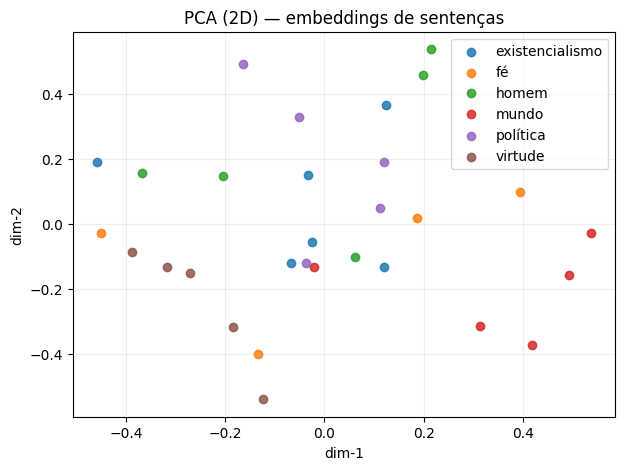

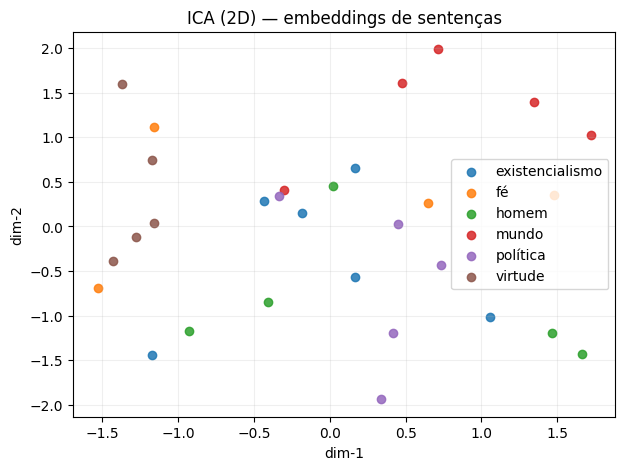

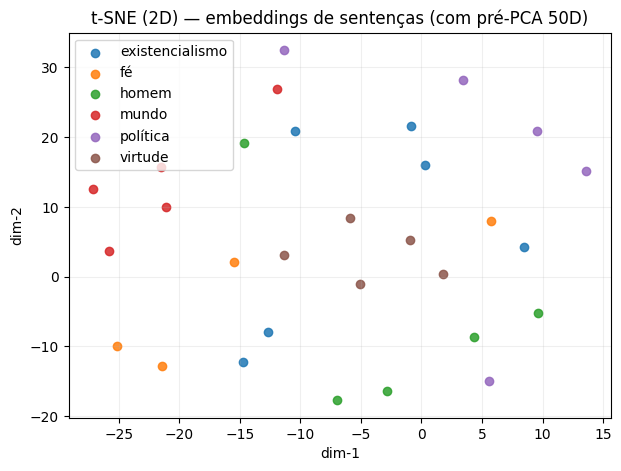

In [17]:
def plot_2d(X2, title: str, df_meta: pd.DataFrame):
    plt.figure(figsize=(7, 5))
    for label, sub in df_meta.groupby("label"):
        idx = sub.index.to_numpy()
        plt.scatter(X2[idx, 0], X2[idx, 1], label=label, alpha=0.85)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_2d(X_pca2, "PCA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_ica2, "ICA (2D) — embeddings de sentenças", df_sents)
plot_2d(X_tsne2, "t-SNE (2D) — embeddings de sentenças (com pré-PCA 50D)", df_sents)


PCA e t-SNE tiverem clusters claro com o tema virtude e mundo.

Existem sentenças foras do lugar devido a caracteristica das fras que falam em mais de um dos topicos.

## 7) Embedding por documento (agregação)

Às vezes você quer um embedding **por documento**, não por sentença.  
Uma forma simples é fazer **média** dos embeddings das sentenças do documento (pode funcionar razoavelmente).

Depois, repita PCA/t-SNE para visualizar documentos.


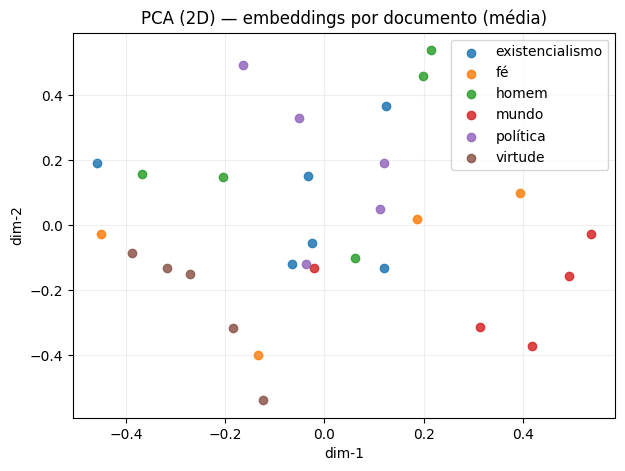

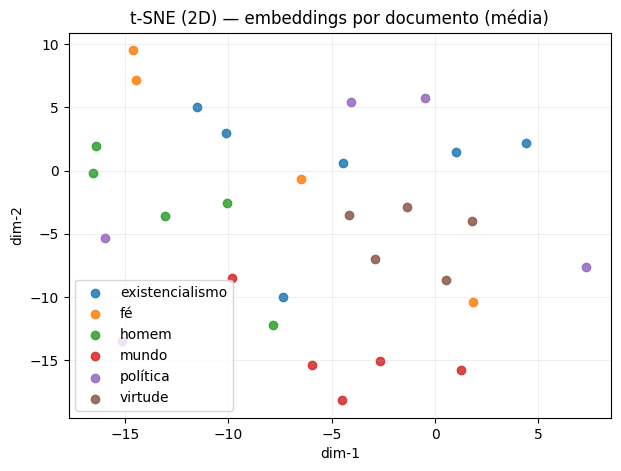

,doc_id,label
0,e1,existencialismo
1,e2,existencialismo
2,e3,existencialismo
3,e4,existencialismo
4,e5,existencialismo
5,e6,existencialismo
6,f1,fé
7,f2,fé
8,f3,fé
9,f4,fé


In [18]:
# Agrega por doc: média dos vetores das sentenças
df_doc_emb = (
    df_sents
    .groupby(["doc_id", "label"])["embedding"]
    .apply(lambda vs: np.mean(np.vstack(vs), axis=0))
    .reset_index()
)

X_doc = np.vstack(df_doc_emb["embedding"].to_numpy())

# PCA 2D
X_doc_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_doc)

# t-SNE 2D (sem pré-PCA pois é pequeno)
X_doc_tsne2 = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42,
).fit_transform(X_doc)

plot_2d(X_doc_pca2, "PCA (2D) — embeddings por documento (média)", df_doc_emb)
plot_2d(X_doc_tsne2, "t-SNE (2D) — embeddings por documento (média)", df_doc_emb)

df_doc_emb[["doc_id", "label"]]


# Exercícios

## Exercício A — Substitua o dataset
1. Use outro dataset com **50 a 150 documentos**, com **3 a 5 tópicos** (ex.: política, saúde, cultura, tecnologia, esporte).
2. Quebre em sentenças.
3. Gere embeddings e visualize com PCA e t-SNE.
4. Escreva 3 observações:
   - Algum tópico formou cluster claro?
   - Há sentenças “fora do lugar”? Por quê?
   - O que muda ao trocar o modelo (inglês vs multilíngue)?

## Exercício B — Variações de t-SNE
1. Teste `perplexity` em {5, 10, 30}. 1º Alteramos para 10
2. Teste `init` em {"pca", "random"}. 1º invertemos, e tivemos quase  nenhum cluster.
3. Compare estabilidade visual (semente fixa vs outra).

## Exercício C — PCA antes do t-SNE
1. Rode t-SNE com e sem PCA prévio (50D).
2. Compare tempo e qualidade da separação.

---
